# Unit Distance Analysis

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import scipy.linalg
from scipy.optimize import minimize

## Generate Random Distribution of Points

In [38]:
num = 10000
rng = np.random.default_rng(seed=42)

In [39]:
def mitchells_best_candidate(num_samples, candidates_per_step=20, rng=None):
    # Initialize first point randomly
    points = np.random.rand(1, 2)
    
    for _ in range(num_samples - 1):
        # 1. Generate k random candidates
        if rng is None:
            candidates = np.random.random(size=(candidates_per_step, 2))
        else:
            candidates = rng.uniform(size=(candidates_per_step, 2))
        
        # 2. Compute the distance from every candidate to all existing points
        # Using broadcasting to get shape: (candidates_per_step, existing_points)
        # Using a^2 + b^2 = c^2, but simply squared distances are sufficient for comparison
        dist_matrix = np.sum((candidates[:, np.newaxis, :] - points) ** 2, axis=2)
        
        # 3. Find the minimum distance for each candidate to any existing point
        min_distances = np.min(dist_matrix, axis=1)
        
        # 4. Pick the candidate with the maximum minimum distance
        best_idx = np.argmax(min_distances)
        best_candidate = candidates[best_idx]
        
        # 5. Add best candidate to our array of points
        points = np.vstack([points, best_candidate])
        
    return points

# # Normal distribution:
# xy_coords = rng.normal(size=(num, 2))

# # Uniform distribution:
# xy_coords = rng.uniform(low=-1.0, high=1.0, size=(num, 2))

# # Spaced Points:
xy_coords = mitchells_best_candidate(num, rng=rng)
print(f"{xy_coords.shape=}")

xy_coords.shape=(10000, 2)


In [45]:
x_matrix = scipy.linalg.circulant(xy_coords[:, 0]).T[:, 1:] - xy_coords[:, :1]
y_matrix = scipy.linalg.circulant(xy_coords[:, 1]).T[:, 1:] - xy_coords[:, 1:]
dist2 = np.ravel(
    np.square(x_matrix) + np.square(y_matrix)
)
print(f"{dist2.shape=}")
max_dist = 2 / np.sqrt(num)
# dist2 = dist2[dist2 < np.square(max_dist)]  # Huristic to reduce n-to-n
# print(f"{dist2.shape=}")
del x_matrix
del y_matrix

dist2.shape=(99990000,)


## Scatter Plot & Histogram

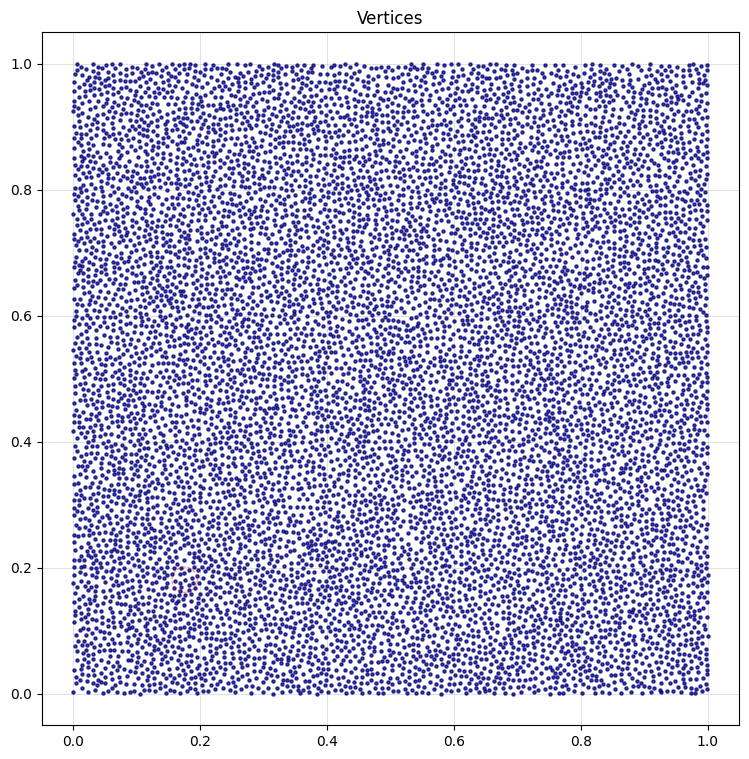

In [46]:
fig = plt.figure(figsize=(9.0, 9.0))
ax = fig.gca()

ax.scatter(xy_coords[:, 0], xy_coords[:, 1], s=5.0, color="navy", alpha=0.75)
ax.set_title("Vertices")
ax.grid(lw=0.5, alpha=0.5, color="darkgrey")
ax.set_axisbelow(True)

for idx in range(xy_coords.shape[0]):
    circle = patches.Circle(
        xy_coords[idx, :], 
        radius=max_dist,        # Radius size in data units
        edgecolor='red', 
        facecolor='none',       # Keep the circle hollow
        linestyle='--',         # Make the border dashed
        linewidth=0.75,
        alpha=0.5,
        zorder=2,
    )
    ax.add_patch(circle)
    break

plt.show()

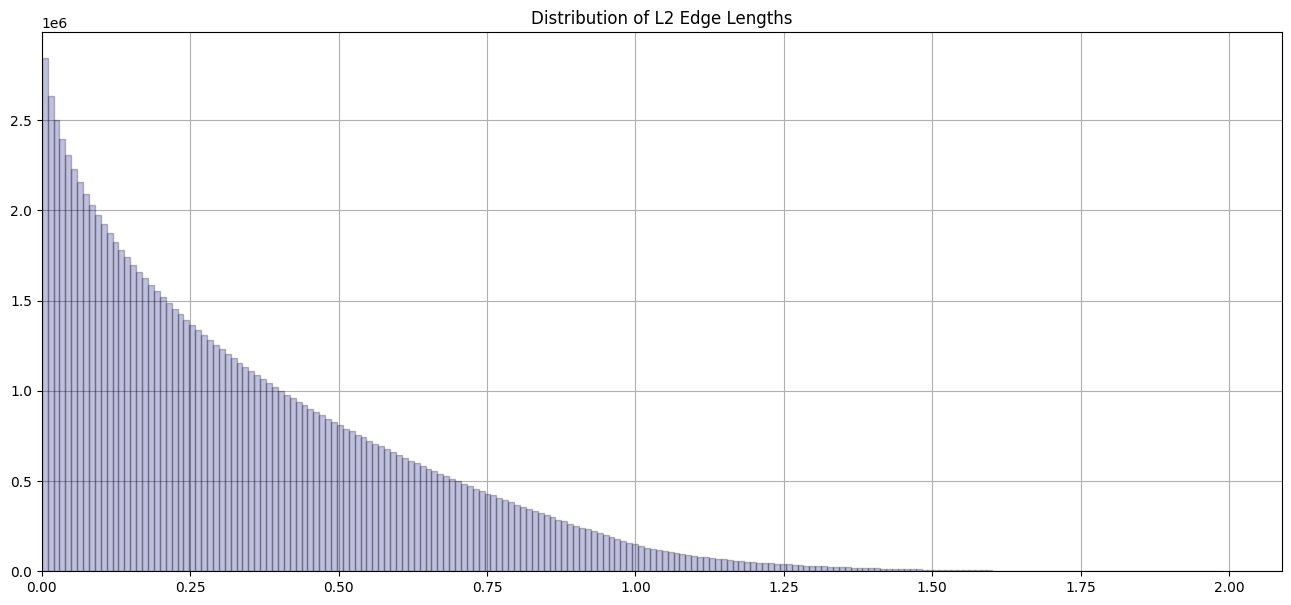

In [47]:
num_bins = 200

fig = plt.figure(figsize=(16.0, 7.0))
ax = fig.gca()

values, bins, _ = ax.hist(
    dist2, bins=num_bins, edgecolor="black", color="navy", alpha=0.25
)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

ax.set_title("Distribution of L2 Edge Lengths")
ax.grid()
ax.set_axisbelow(True)
ax.set_xlim(0.0, )

plt.show()

In [43]:
# fig = plt.figure(figsize=(16.0, 7.0))
# ax = fig.gca()

# ax.plot(
#     bin_centers, values * np.exp(-1.0 * np.square(bin_centers - 1)),
#     color="navy", alpha=0.25,
# )
# print(np.sum(values * np.exp(-1.0 * np.square(bin_centers - 1))))
# ax.set_title("Objective Function")
# ax.grid()
# ax.set_axisbelow(True)
# ax.set_xlim(0.0, )

# plt.show()

In [44]:
print(np.sum(values * np.exp(-1.0 * np.square(bin_centers - 1))) / num ** 2)
print(np.sum(np.exp(-1.0 * np.square(dist2 - 1))) / num ** 2)

0.00045442141177935415
0.000454421339060765


In [17]:
# fig = plt.figure(figsize=(16.0, 7.0))
# ax = fig.gca()

# objective_array = np.exp(-1.0 * np.square(dist2 - 1))
# print(f"{objective_array.shape=}\n{objective_array.mean()=}\n{objective_array.std()=}")
# values, bins, _ = ax.hist(
#     objective_array, bins=100, edgecolor="black", color="navy", alpha=0.25,
# )
# ax.set_title("Distribution of Objective")
# ax.grid()
# ax.set_axisbelow(True)
# # ax.set_xlim(0.0, )
# # ax.set_yscale("log")
# # ax.set_xscale("log")

# plt.show()

## Optimize Using SciPy